# Exp5 IIITD-CLI  Notebook B: Rich Multi-Field TDA Feature Extraction + TDA-Only Baseline
**Goal:** Extract ~550+ raw topological features per image (up from ~28-34 in
earlier versions), then select down to a compact, stable, informative set,
and evaluate whether topology ALONE carries independent PAD signal across
all 5 protocols. This directly feeds Notebook C's CNN+TDA fusion.

---

## Why more features, and where they come from

| Axis | Values | Count |
|---|---|---|
| Image-derived field | intensity, gradient magnitude, LBP, Gabor magnitude | 4 |
| ROI (radial zone) | inner annulus, middle annulus, outer annulus | 3 |
| Homology dimension | H0 (components), H1 (loops) | 2 |
| **Diagrams per image** | 4 \u00d7 3 \u00d7 2 | **24** |
| Descriptors per diagram | persistence stats(5), entropy(1), birth stats(4), death stats(4), betti-at-5-scales(5), landscape area(1), bar count(1) | 21 |
| **Raw features per image** | 24 \u00d7 21 + amplitude (2 metrics \u00d7 12 field-ROI-dim combos) | **~528** |



## 1. Imports

In [9]:
# Cell 1
# ---------------------------------------------------------------------------
# Imports. ripser for persistent homology. cv2 for Sobel/Gabor. No extra
# dependency for LBP -- implemented manually with numpy below.
# ---------------------------------------------------------------------------
import os, json, warnings, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from pathlib import Path
from PIL import Image
from scipy.stats import entropy as scipy_entropy
from scipy.stats import mannwhitneyu, spearmanr

try:
    from ripser import ripser
except ImportError:
    raise ImportError("ripser not installed. Run: pip install ripser --break-system-packages")

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import confusion_matrix, roc_curve, auc, accuracy_score
from sklearn.feature_selection import mutual_info_classif, VarianceThreshold
from sklearn.preprocessing import StandardScaler

try:
    from tqdm import tqdm
except ImportError:
    def tqdm(it, **kwargs): return it

warnings.filterwarnings('ignore')
np.random.seed(42)
torch.manual_seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
print('Imports OK \u2713')


Device: cuda
Imports OK ✓


## 2. Config

In [10]:
# Cell 2
# ---------------------------------------------------------------------------
# Config. Paths point at Notebook A's saved outputs (master_raw_index.csv,
# protocol manifests) -- Notebook B builds on top of those, never redoing
# the parsing/splitting work.
# ---------------------------------------------------------------------------
PROJECT_ROOT = Path(r"C:\Users\sahar\OneDrive\Desktop\EXPLAINABLE_IRIS_PAD")
EXP_NAME     = 'Exp5_IIITD_CrossSensor_5Protocol'
EXP_DIR      = PROJECT_ROOT / 'Experiments' / EXP_NAME

SPLITS_DIR   = EXP_DIR / 'outputs' / 'splits'     # from Notebook A
METRICS_DIR  = EXP_DIR / 'outputs' / 'metrics'    # from Notebook A

TDA_DIR         = EXP_DIR / 'outputs' / 'tda'
TDA_RAW_DIR     = TDA_DIR / 'raw_features'
TDA_SELECTED_DIR= TDA_DIR / 'selected_features'
TDA_MODELS_DIR  = TDA_DIR / 'models'
TDA_FIGURES_DIR = TDA_DIR / 'figures'
TDA_DET_DIR     = TDA_FIGURES_DIR / 'det_curves'

for d in [TDA_DIR, TDA_RAW_DIR, TDA_SELECTED_DIR, TDA_MODELS_DIR, TDA_FIGURES_DIR, TDA_DET_DIR]:
    d.mkdir(parents=True, exist_ok=True)

PROTOCOL_NAMES = ['P1_Cogent_to_Cogent', 'P2_Vista_to_Vista',
                  'P3_Cogent_to_Vista', 'P4_Vista_to_Cogent', 'P5_Combined']

TDA_CONFIG = {
    'img_resize':          64,     # resize before point cloud extraction (speed)
    'threshold_percentile': 70,    # bright-pixel threshold, as a percentile (adaptive per field)
    'max_points':          150,    # point cloud cap per (field, ROI)
    'min_points':          8,      # skip diagram if fewer than this many points
    'maxdim':              1,      # H0 and H1 only
    'betti_n_scales':      5,
    'betti_n_bins':        50,
    'n_stability_samples': 300,    # images used for the stability test
    'stability_threshold': 0.5,    # min |correlation| to keep a feature as 'stable'
    'corr_threshold':      0.90,
    'n_selected_features': 128,    # per-protocol MI-selected feature count
    'checkpoint_every':    200,    # save partial results every N images
}

# ROI zones: fraction of max radius, e.g. (0.0,0.33) = inner annulus
ROI_ZONES = {
    'inner':  (0.00, 0.33),
    'middle': (0.33, 0.66),
    'outer':  (0.66, 1.00),
}
FIELD_NAMES = ['intensity', 'gradient', 'lbp', 'gabor']

print('Config ready \u2713')
print(f'TDA output dir: {TDA_DIR}')
print(f'ROI zones     : {list(ROI_ZONES.keys())}')
print(f'Fields        : {FIELD_NAMES}')
print(f'Expected raw features per image: '
      f'{len(FIELD_NAMES) * len(ROI_ZONES) * (TDA_CONFIG["maxdim"]+1)} diagrams '
      f'x ~21 descriptors + amplitude \u2248 528+')


Config ready ✓
TDA output dir: C:\Users\sahar\OneDrive\Desktop\EXPLAINABLE_IRIS_PAD\Experiments\Exp5_IIITD_CrossSensor_5Protocol\outputs\tda
ROI zones     : ['inner', 'middle', 'outer']
Fields        : ['intensity', 'gradient', 'lbp', 'gabor']
Expected raw features per image: 24 diagrams x ~21 descriptors + amplitude ≈ 528+


## 3. Load Notebook A's Master Index + 5 Protocol Manifests

In [13]:
# Cell 3
# ---------------------------------------------------------------------------
# Load Notebook A's master raw index (all Cogent+Vista original images) and
# the 5 protocol manifests. TDA features are computed ONCE per unique image
# path (not per protocol) -- a given Cogent image can appear in P1, P3-train,
# P4-test, and P5, and we do not want to recompute its topology 4 times.
# ---------------------------------------------------------------------------
master_raw = pd.read_csv(SPLITS_DIR / 'master_raw_index.csv')
print(f'Master raw index: {len(master_raw)} unique images '
      f'({master_raw["sensor"].value_counts().to_dict()})')

protocols = {}
for name in PROTOCOL_NAMES:
    protocols[name] = {
        'train_df': pd.read_csv(SPLITS_DIR / f'{name}_train.csv'),
        'val_df':   pd.read_csv(SPLITS_DIR / f'{name}_val.csv'),
        'test_df':  pd.read_csv(SPLITS_DIR / f'{name}_test.csv'),
    }
    tr, va, te = protocols[name]['train_df'], protocols[name]['val_df'], protocols[name]['test_df']
    print(f'  {name:22s}: train={len(tr):5d}  val={len(va):5d}  test={len(te):5d}')

print('\nLoaded master index + 5 protocol manifests \u2713')


Master raw index: 4328 unique images ({'Cogent': 2323, 'Vista': 2005})
  P1_Cogent_to_Cogent   : train= 1622  val=  331  test=  370
  P2_Vista_to_Vista     : train= 1385  val=  300  test=  320
  P3_Cogent_to_Vista    : train= 1960  val=  363  test= 2005
  P4_Vista_to_Cogent    : train= 1685  val=  320  test= 2323
  P5_Combined           : train= 3007  val=  631  test=  690

Loaded master index + 5 protocol manifests ✓


## 4. Multi-Field Extraction Functions (intensity, gradient, LBP, Gabor)

In [14]:
# Cell 4
# ---------------------------------------------------------------------------
# Multi-field extraction. Each function takes a grayscale image (uint8,
# resized) and returns a same-size float32 response map. These responses
# are what gets thresholded into a point cloud per ROI zone.
# ---------------------------------------------------------------------------

def field_intensity(gray):
    # Raw pixel intensity -- baseline field, captures overall texture.
    return gray.astype(np.float32)

def field_gradient(gray):
    # Sobel gradient magnitude -- captures edge/boundary structure
    # (iris crypt/furrow edges, print-artifact boundaries).
    gx = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)
    return cv2.magnitude(gx, gy)

def field_lbp(gray, radius=1):
    # Manual 8-neighbor Local Binary Pattern -- captures micro-texture
    # patterns (iris fibrous structure vs smooth printed/lens texture).
    h, w = gray.shape
    g = gray.astype(np.int16)
    lbp = np.zeros((h, w), dtype=np.float32)
    offsets = [(-1,-1),(-1,0),(-1,1),(0,1),(1,1),(1,0),(1,-1),(0,-1)]
    padded = np.pad(g, radius, mode='edge')
    for bit, (dy, dx) in enumerate(offsets):
        shifted = padded[radius+dy:radius+dy+h, radius+dx:radius+dx+w]
        lbp += ((shifted >= g).astype(np.float32)) * (2 ** bit)
    return lbp

def field_gabor(gray):
    # Gabor filter magnitude, averaged over 4 orientations -- captures
    # frequency/orientation-specific texture (iris furrow directionality).
    responses = []
    for theta in [0, np.pi/4, np.pi/2, 3*np.pi/4]:
        kernel = cv2.getGaborKernel((9,9), sigma=3.0, theta=theta,
                                    lambd=6.0, gamma=0.5, psi=0)
        responses.append(np.abs(cv2.filter2D(gray.astype(np.float32), cv2.CV_32F, kernel)))
    return np.mean(responses, axis=0)

FIELD_FUNCS = {
    'intensity': field_intensity,
    'gradient':  field_gradient,
    'lbp':       field_lbp,
    'gabor':     field_gabor,
}

print('4 field extraction functions defined \u2713')


4 field extraction functions defined ✓


## 5. ROI Zone Masks (inner/middle/outer radial annuli)

In [15]:
# Cell 5
# ---------------------------------------------------------------------------
# ROI zone masks -- concentric radial bands from image center. See header
# note: this is a documented heuristic, not verified iris segmentation.
# ---------------------------------------------------------------------------
def make_roi_masks(size):
    h = w = size
    cy, cx = h / 2, w / 2
    max_r = np.sqrt(cy**2 + cx**2)
    yy, xx = np.mgrid[0:h, 0:w]
    dist = np.sqrt((yy - cy)**2 + (xx - cx)**2) / max_r  # normalized [0,1]

    masks = {}
    for zone_name, (r_min, r_max) in ROI_ZONES.items():
        masks[zone_name] = (dist >= r_min) & (dist < r_max)
    return masks

_ROI_MASKS_CACHE = make_roi_masks(TDA_CONFIG['img_resize'])
print(f'ROI masks built for {TDA_CONFIG["img_resize"]}x{TDA_CONFIG["img_resize"]} images:')
for name, mask in _ROI_MASKS_CACHE.items():
    print(f'  {name:8s}: {mask.sum()} pixels ({100*mask.sum()/mask.size:.1f}% of image)')


ROI masks built for 64x64 images:
  inner   : 697 pixels (17.0% of image)
  middle  : 2104 pixels (51.4% of image)
  outer   : 1294 pixels (31.6% of image)


## 6. Point Cloud Extraction (per field x ROI)

In [17]:
# Cell 5
# ---------------------------------------------------------------------------
# Point cloud extraction: threshold a field-response map WITHIN a given ROI
# mask, return normalized (row,col) coordinates.
# ---------------------------------------------------------------------------
def response_to_point_cloud(response_map, roi_mask, config):
    masked = response_map.copy()
    masked[~roi_mask] = -np.inf   # exclude pixels outside this ROI zone

    valid_vals = masked[roi_mask]
    if len(valid_vals) < config['min_points']:
        return None

    thresh = np.percentile(valid_vals, config['threshold_percentile'])
    rows, cols = np.where(masked > thresh)
    if len(rows) < config['min_points']:
        return None

    pts = np.column_stack([rows, cols]).astype(np.float32)
    pts = pts / (config['img_resize'] - 1)  # normalize to [0,1]^2

    if len(pts) > config['max_points']:
        idx = np.random.choice(len(pts), config['max_points'], replace=False)
        pts = pts[idx]
    return pts

print('response_to_point_cloud() defined \u2713')


response_to_point_cloud() defined ✓


## 7. Rich Descriptor Set (21 descriptors per persistence diagram)

In [18]:
# Cell 6
# ---------------------------------------------------------------------------
# Rich descriptor set per persistence diagram (21 descriptors). Same
# mathematical definitions established in earlier notebooks, applied here
# per (field, ROI, homology_dim) combination.
# ---------------------------------------------------------------------------
_trapz = np.trapezoid if hasattr(np, 'trapezoid') else np.trapz
MAX_RADIUS = float(np.sqrt(2))
BETTI_THRESHOLDS = np.linspace(0, MAX_RADIUS, TDA_CONFIG['betti_n_bins'])

def _finite(dgm):
    if len(dgm) == 0:
        return np.zeros((0, 2))
    return dgm[np.isfinite(dgm[:, 1])]

def persistence_stats(dgm):
    f = _finite(dgm)
    if len(f) == 0: return (0.,0.,0.,0.,0.)
    p = f[:,1] - f[:,0]; p = p[p > 0]
    if len(p) == 0: return (0.,0.,0.,0.,0.)
    return float(p.mean()), float(p.std()), float(p.max()), float(p.min()), float(p.sum())

def persistence_entropy(dgm):
    f = _finite(dgm)
    if len(f) == 0: return 0.
    p = f[:,1] - f[:,0]; p = p[p > 0]
    if len(p) == 0: return 0.
    p = p / p.sum()
    return float(scipy_entropy(p))

def birth_death_stats(dgm):
    f = _finite(dgm)
    if len(f) == 0: return (0.,0.,0.,0.), (0.,0.,0.,0.)
    b, d = f[:,0], f[:,1]
    birth_stats = (float(b.mean()), float(b.std()), float(b.max()), float(b.min()))
    death_stats = (float(d.mean()), float(d.std()), float(d.max()), float(d.min()))
    return birth_stats, death_stats

def betti_curve(dgm, thresholds=BETTI_THRESHOLDS):
    if len(dgm) == 0:
        return np.zeros(len(thresholds))
    b, d = dgm[:,0], dgm[:,1]
    d = np.where(np.isinf(d), MAX_RADIUS * 10, d)
    return np.array([np.sum((b <= t) & (d > t)) for t in thresholds], dtype=np.float32)

def betti_at_scales(betti_vec, n_scales=TDA_CONFIG['betti_n_scales']):
    if len(betti_vec) == 0:
        return np.zeros(n_scales)
    idx = np.linspace(0, len(betti_vec)-1, n_scales, dtype=int)
    return betti_vec[idx]

def landscape_area(dgm, thresholds=BETTI_THRESHOLDS):
    f = _finite(dgm)
    if len(f) == 0: return 0.
    landscape = np.array([
        max(0, max(min(t-b_, d_-t) for b_, d_ in f)) for t in thresholds
    ])
    return float(_trapz(landscape, thresholds))

def extract_descriptors(dgm, prefix):
    # Returns a dict of 21 named descriptors for one persistence diagram.
    feat = {}
    mn, sd, mx, mi, sm = persistence_stats(dgm)
    feat[f'{prefix}_pers_mean'] = mn; feat[f'{prefix}_pers_std'] = sd
    feat[f'{prefix}_pers_max']  = mx; feat[f'{prefix}_pers_min'] = mi
    feat[f'{prefix}_pers_sum']  = sm
    feat[f'{prefix}_entropy']   = persistence_entropy(dgm)
    (bmn,bsd,bmx,bmi), (dmn,dsd,dmx,dmi) = birth_death_stats(dgm)
    feat[f'{prefix}_birth_mean']=bmn; feat[f'{prefix}_birth_std']=bsd
    feat[f'{prefix}_birth_max'] =bmx; feat[f'{prefix}_birth_min']=bmi
    feat[f'{prefix}_death_mean']=dmn; feat[f'{prefix}_death_std']=dsd
    feat[f'{prefix}_death_max'] =dmx; feat[f'{prefix}_death_min']=dmi
    bc = betti_curve(dgm)
    for k, v in enumerate(betti_at_scales(bc)):
        feat[f'{prefix}_betti_s{k}'] = float(v)
    feat[f'{prefix}_landscape_area'] = landscape_area(dgm)
    feat[f'{prefix}_n_bars'] = len(_finite(dgm))
    return feat  # 21 keys

print('21-descriptor extraction function defined \u2713  (per diagram)')


21-descriptor extraction function defined ✓  (per diagram)


## 8. Per-Image Full Extraction Pipeline (~528 raw features)

In [19]:
# Cell 7
# ---------------------------------------------------------------------------
# extract_all_features_for_image(): the per-image pipeline. For each of the
# 4 fields x 3 ROIs, extract a point cloud, compute persistent homology
# (H0+H1), extract 21 descriptors per dim, plus 2 amplitude metrics per
# (field, ROI, dim). Returns a flat dict (~528 keys) or None on failure.
# ---------------------------------------------------------------------------
from scipy.stats import wasserstein_distance

def amplitude_metric(dgm):
    # Simple amplitude: Wasserstein distance of the persistence distribution
    # from a point mass at zero (same definition used in earlier notebooks).
    f = _finite(dgm)
    if len(f) == 0: return 0.
    p = f[:,1] - f[:,0]
    if len(p) == 0: return 0.
    return float(wasserstein_distance(p, [0.0]))


def extract_all_features_for_image(img_path, config):
    try:
        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
        if img is None:
            pil_img = Image.open(img_path).convert('L')
            img = np.array(pil_img)
        img = cv2.resize(img, (config['img_resize'], config['img_resize']))
    except Exception:
        return None

    feat = {}
    for field_name, field_fn in FIELD_FUNCS.items():
        response = field_fn(img)
        for roi_name, roi_mask in _ROI_MASKS_CACHE.items():
            pc = response_to_point_cloud(response, roi_mask, config)
            prefix_base = f'{field_name}_{roi_name}'

            if pc is None or len(pc) < 2:
                # Fill zeros for both dims if extraction failed for this combo
                for dim in range(config['maxdim'] + 1):
                    dummy = extract_descriptors(np.zeros((0,2)), f'{prefix_base}_H{dim}')
                    feat.update(dummy)
                    feat[f'{prefix_base}_H{dim}_amp'] = 0.
                continue

            try:
                result = ripser(pc, maxdim=config['maxdim'])
                dgms = result['dgms']
            except Exception:
                for dim in range(config['maxdim'] + 1):
                    dummy = extract_descriptors(np.zeros((0,2)), f'{prefix_base}_H{dim}')
                    feat.update(dummy)
                    feat[f'{prefix_base}_H{dim}_amp'] = 0.
                continue

            for dim in range(config['maxdim'] + 1):
                dgm = dgms[dim] if dim < len(dgms) else np.zeros((0,2))
                prefix = f'{prefix_base}_H{dim}'
                feat.update(extract_descriptors(dgm, prefix))
                feat[f'{prefix}_amp'] = amplitude_metric(dgm)

    return feat

# Quick sanity test on the first image
_test_row = master_raw.iloc[0]
_test_feat = extract_all_features_for_image(_test_row['path'], TDA_CONFIG)
print(f'Test extraction on: {_test_row["path"]}')
print(f'Features extracted: {len(_test_feat)}  (expected ~{4*3*2*21 + 4*3*2} = {4*3*2*21 + 4*3*2})')


Test extraction on: C:\Users\sahar\OneDrive\Desktop\EXPLAINABLE_IRIS_PAD\Data\Raw\IIITD_Contact_Lens_Iris_DB\Cogent Scanner\1\Colored\20120914164317_L.bmp
Features extracted: 528  (expected ~528 = 528)


## 9. MAIN EXTRACTION LOOP (all unique images, resumable, checkpointed)

**This is the expensive one-time step.** ~155,000 persistent homology
computations total. Safe to interrupt  re-running this cell resumes from
the last checkpoint (already-processed image paths are skipped).


In [20]:
# Cell 8
# ---------------------------------------------------------------------------
# MAIN EXTRACTION LOOP -- resumable, checkpointed every N images. This is
# the expensive one-time step (see header warning). Safe to interrupt and
# re-run: already-processed image paths are skipped.
# ---------------------------------------------------------------------------
MASTER_TDA_PATH = TDA_RAW_DIR / 'master_tda_features.csv'

if MASTER_TDA_PATH.exists():
    existing_df = pd.read_csv(MASTER_TDA_PATH)
    processed_paths = set(existing_df['path'])
    print(f'Resuming: {len(processed_paths)} images already processed.')
else:
    existing_df = pd.DataFrame()
    processed_paths = set()
    print('Starting fresh extraction.')

remaining = master_raw[~master_raw['path'].isin(processed_paths)].reset_index(drop=True)
print(f'Remaining to process: {len(remaining)} / {len(master_raw)}')

if len(remaining) == 0:
    print('All images already processed \u2713 (skipping extraction loop)')
    master_tda_df = existing_df
else:
    new_records = []
    checkpoint_every = TDA_CONFIG['checkpoint_every']

    for idx, row in enumerate(tqdm(remaining.itertuples(), total=len(remaining), desc='Extracting TDA')):
        feats = extract_all_features_for_image(row.path, TDA_CONFIG)
        if feats is None:
            continue
        rec = {
            'path': row.path, 'subject_uid': row.subject_uid,
            'sensor': row.sensor, 'label': int(row.label),
        }
        rec.update(feats)
        new_records.append(rec)

        if (idx + 1) % checkpoint_every == 0:
            partial_df = pd.DataFrame(new_records)
            combined = pd.concat([existing_df, partial_df], ignore_index=True) if len(existing_df) else partial_df
            combined.to_csv(MASTER_TDA_PATH, index=False)
            print(f'  [CHECKPOINT] {len(combined)} images saved so far...')

    final_new_df = pd.DataFrame(new_records)
    master_tda_df = pd.concat([existing_df, final_new_df], ignore_index=True) if len(existing_df) else final_new_df
    master_tda_df.to_csv(MASTER_TDA_PATH, index=False)

print(f'\nExtraction complete. Master TDA feature table: {len(master_tda_df)} images '
      f'x {len(master_tda_df.columns)} columns (~{len(master_tda_df.columns)-4} raw TDA features)')
print(f'Saved -> {MASTER_TDA_PATH}')


Starting fresh extraction.
Remaining to process: 4328 / 4328


Extracting TDA:   5%|▍         | 200/4328 [02:01<41:35,  1.65it/s]  

  [CHECKPOINT] 200 images saved so far...


Extracting TDA:   9%|▉         | 400/4328 [03:46<1:00:44,  1.08it/s]

  [CHECKPOINT] 400 images saved so far...


...

  [CHECKPOINT] 4000 images saved so far...


Extracting TDA:  97%|█████████▋| 4200/4328 [43:45<03:59,  1.87s/it]

  [CHECKPOINT] 4200 images saved so far...


Extracting TDA: 100%|██████████| 4328/4328 [44:52<00:00,  1.61it/s]



Extraction complete. Master TDA feature table: 4328 images x 532 columns (~528 raw TDA features)
Saved -> C:\Users\sahar\OneDrive\Desktop\EXPLAINABLE_IRIS_PAD\Experiments\Exp5_IIITD_CrossSensor_5Protocol\outputs\tda\raw_features\master_tda_features.csv


## 10. Visual Field/ROI Extraction Audit

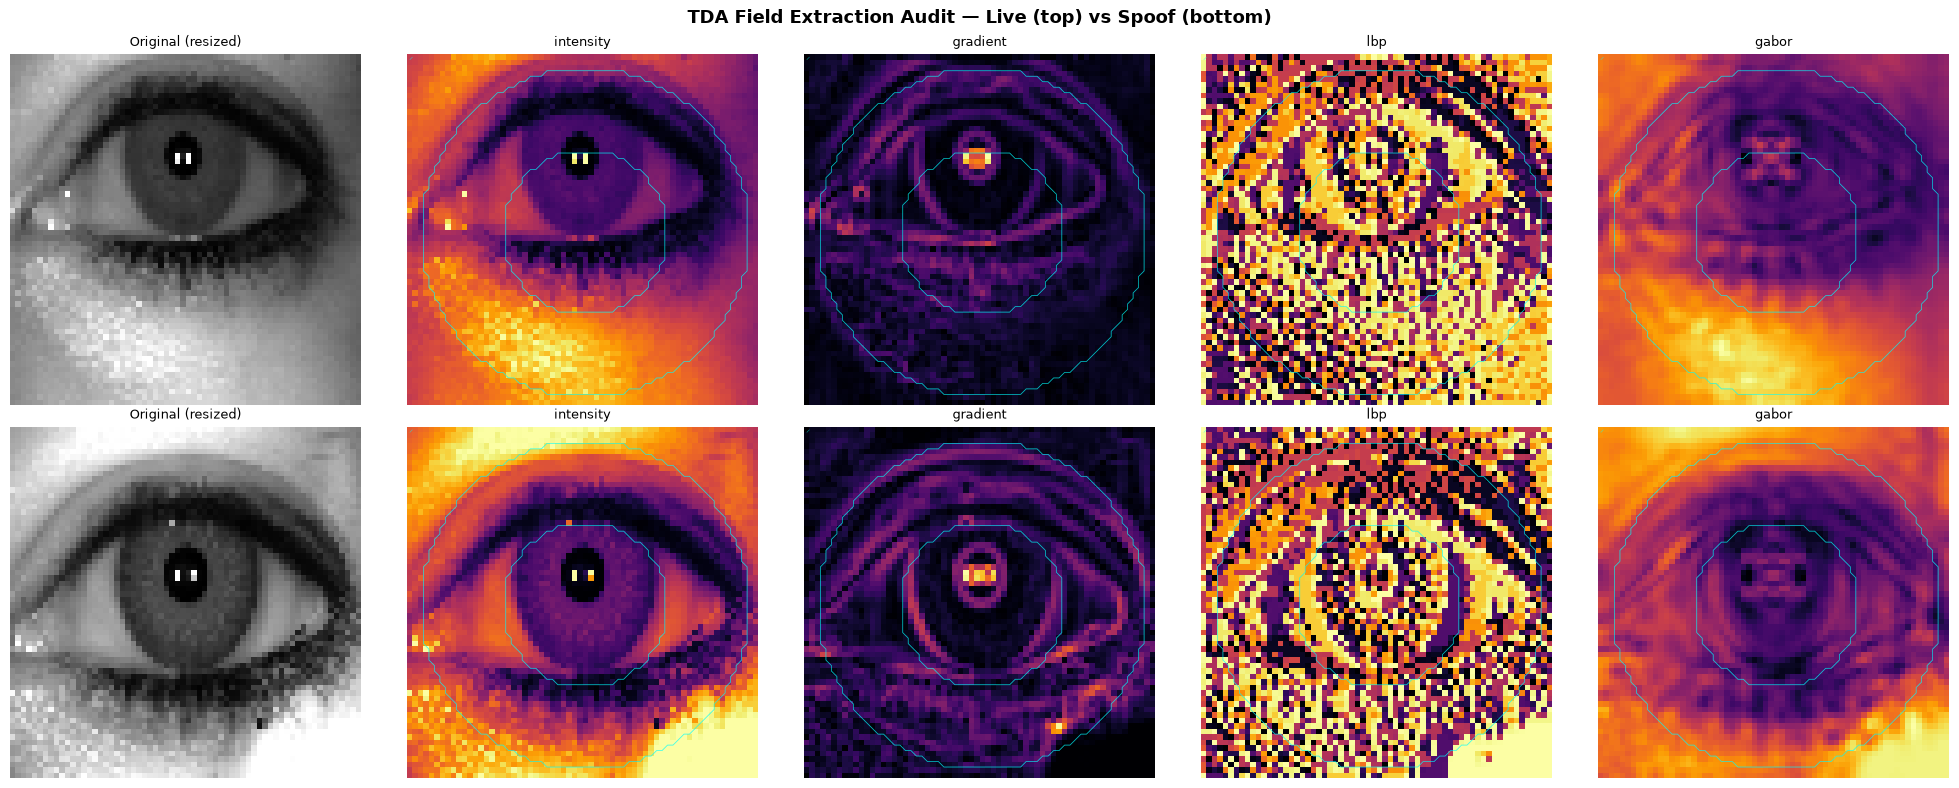

Saved -> field_extraction_audit.png  (cyan lines = ROI zone boundaries)


In [21]:
# Cell 9
# ---------------------------------------------------------------------------
# Visual audit: show the 4 field-response maps + 3 ROI zone overlays for
# one Live and one Spoof example, so extraction quality can be sanity-
# checked before trusting the downstream features.
# ---------------------------------------------------------------------------
sample_live  = master_raw[master_raw['label']==0].iloc[0]
sample_spoof = master_raw[master_raw['label']==1].iloc[0]

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle('TDA Field Extraction Audit \u2014 Live (top) vs Spoof (bottom)',
             fontsize=13, fontweight='bold')

for row_i, sample in enumerate([sample_live, sample_spoof]):
    img = cv2.imread(str(sample['path']), cv2.IMREAD_GRAYSCALE)
    if img is None:
        img = np.array(Image.open(sample['path']).convert('L'))
    img = cv2.resize(img, (TDA_CONFIG['img_resize'], TDA_CONFIG['img_resize']))

    axes[row_i][0].imshow(img, cmap='gray')
    axes[row_i][0].set_title('Original (resized)', fontsize=9)
    axes[row_i][0].axis('off')

    for col_i, (field_name, field_fn) in enumerate(FIELD_FUNCS.items(), start=1):
        response = field_fn(img)
        axes[row_i][col_i].imshow(response, cmap='inferno')
        axes[row_i][col_i].set_title(field_name, fontsize=9)
        axes[row_i][col_i].axis('off')
        # Overlay ROI zone boundaries
        for roi_name, mask in _ROI_MASKS_CACHE.items():
            axes[row_i][col_i].contour(mask, colors='cyan', linewidths=0.5, alpha=0.5)

plt.tight_layout()
plt.savefig(TDA_FIGURES_DIR / 'field_extraction_audit.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved -> field_extraction_audit.png  (cyan lines = ROI zone boundaries)')


## 11. Stability Test (perturbation-based feature pruning)

Features that change drastically under a MILD rotation+noise perturbation
are noise-driven, not genuine topological signal \u2014 they are dropped before
any selection/training happens.


In [22]:
# Cell 10
# ---------------------------------------------------------------------------
# Stability test: for a subsample of images, apply MILD perturbations
# (small rotation + mild noise), recompute TDA features, and measure the
# Spearman rank correlation between original and perturbed feature values
# across the subsample. Features with low |correlation| are UNSTABLE (noise-
# driven, not genuine topological signal) and are dropped before selection.
# ---------------------------------------------------------------------------
def perturb_image_mild(img_path, config):
    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        img = np.array(Image.open(img_path).convert('L'))
    img = cv2.resize(img, (config['img_resize'], config['img_resize']))
    # Mild rotation (+/- 3 degrees) + mild gaussian noise
    angle = np.random.uniform(-3, 3)
    h, w = img.shape
    M = cv2.getRotationMatrix2D((w/2, h/2), angle, 1.0)
    rotated = cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REFLECT)
    noisy = np.clip(rotated.astype(np.float32) + np.random.normal(0, 3, rotated.shape), 0, 255).astype(np.uint8)
    return noisy


def run_stability_test(master_tda_df, master_raw, config):
    feat_cols = [c for c in master_tda_df.columns if c not in ('path','subject_uid','sensor','label')]
    n_sample = min(config['n_stability_samples'], len(master_tda_df))
    sample_df = master_tda_df.sample(n_sample, random_state=42)

    orig_vals = sample_df[feat_cols].values
    perturbed_vals = []

    print(f'Running stability test on {n_sample} images '
          f'(mild rotation + noise, recompute features)...')
    for _, row in tqdm(sample_df.iterrows(), total=n_sample, desc='Stability test'):
        perturbed_img_arr = perturb_image_mild(row['path'], config)
        # Save perturbed array to a temp in-memory "path" workaround: write
        # directly via a modified extraction that takes an array. For
        # simplicity, save a temp file.
        tmp_path = TDA_RAW_DIR / '_tmp_perturbed.png'
        cv2.imwrite(str(tmp_path), perturbed_img_arr)
        feats = extract_all_features_for_image(tmp_path, config)
        if feats is None:
            feats = {c: 0.0 for c in feat_cols}
        perturbed_vals.append([feats.get(c, 0.0) for c in feat_cols])

    perturbed_vals = np.array(perturbed_vals)

    stability_scores = {}
    for i, col in enumerate(feat_cols):
        try:
            rho, _ = spearmanr(orig_vals[:, i], perturbed_vals[:, i])
            stability_scores[col] = rho if not np.isnan(rho) else 0.0
        except Exception:
            stability_scores[col] = 0.0

    stability_df = pd.DataFrame({
        'feature': list(stability_scores.keys()),
        'stability_rho': list(stability_scores.values()),
    }).sort_values('stability_rho', ascending=False)

    stable_features = stability_df[
        stability_df['stability_rho'].abs() >= config['stability_threshold']
    ]['feature'].tolist()

    return stability_df, stable_features


stability_path = TDA_RAW_DIR / 'stability_scores.csv'
if stability_path.exists():
    print('[LOAD] Stability scores already computed, loading...')
    stability_df = pd.read_csv(stability_path)
    stable_features = stability_df[
        stability_df['stability_rho'].abs() >= TDA_CONFIG['stability_threshold']
    ]['feature'].tolist()
else:
    stability_df, stable_features = run_stability_test(master_tda_df, master_raw, TDA_CONFIG)
    stability_df.to_csv(stability_path, index=False)

print(f'\nStability test complete.')
print(f'Total raw features        : {len(stability_df)}')
print(f'Stable features (|rho|>={TDA_CONFIG["stability_threshold"]}): {len(stable_features)}')
print(f'\nTop 10 most stable features:')
print(stability_df.head(10).to_string(index=False))
print(f'\nBottom 10 least stable (will be dropped):')
print(stability_df.tail(10).to_string(index=False))


Running stability test on 300 images (mild rotation + noise, recompute features)...


Stability test: 100%|██████████| 300/300 [03:48<00:00,  1.31it/s]



Stability test complete.
Total raw features        : 528
Stable features (|rho|>=0.5): 197

Top 10 most stable features:
                     feature  stability_rho
 intensity_outer_H0_betti_s0       1.000000
   intensity_outer_H0_n_bars       1.000000
 intensity_outer_H0_betti_s3       1.000000
 intensity_outer_H0_pers_min       1.000000
 intensity_outer_H0_betti_s4       1.000000
intensity_outer_H0_death_min       1.000000
   gabor_outer_H0_death_mean       0.875928
          gabor_outer_H0_amp       0.875928
    gabor_outer_H0_pers_mean       0.875928
          gabor_inner_H0_amp       0.855155

Bottom 10 least stable (will be dropped):
                      feature  stability_rho
     gabor_inner_H0_birth_max       0.000000
intensity_middle_H1_birth_min      -0.005113
        lbp_inner_H1_pers_min      -0.017215
       lbp_middle_H1_pers_min      -0.022135
            lbp_middle_H1_amp      -0.027304
      lbp_middle_H1_pers_mean      -0.027304
    gabor_middle_H1_birth_min      -

## 12. Per-Protocol Feature Selection Function (stable → variance → correlation → MI)

In [23]:
# Cell 11
# ---------------------------------------------------------------------------
# Per-protocol feature selection pipeline (train-only, no leakage):
#   Stage 1: keep only STABLE features (from stability test above)
#   Stage 2: variance filter (drop near-constant features)
#   Stage 3: correlation filter (drop redundant pairs, |r|>0.90)
#   Stage 4: mutual information ranking (keep top-N)
# ---------------------------------------------------------------------------
def select_features_for_protocol(train_feat_df, stable_features, config):
    candidate_cols = [c for c in stable_features if c in train_feat_df.columns]
    X = train_feat_df[candidate_cols].fillna(0).values.astype(np.float64)
    y = train_feat_df['label'].values

    # Stage 2: variance filter
    vt = VarianceThreshold(threshold=1e-6)
    vt.fit(X)
    kept_var = [c for c, k in zip(candidate_cols, vt.get_support()) if k]
    X_var = X[:, vt.get_support()]
    print(f'    Stage 1 (stable)     : {len(candidate_cols):4d} candidates')
    print(f'    Stage 2 (variance)   : {len(kept_var):4d} kept')

    # Stage 3: correlation filter
    if X_var.shape[1] > 1:
        corr = np.corrcoef(X_var, rowvar=False)
        drop = set()
        for i in range(corr.shape[0]):
            if i in drop: continue
            for j in range(i+1, corr.shape[0]):
                if j not in drop and abs(corr[i, j]) > config['corr_threshold']:
                    drop.add(j)
        kept_corr = [c for idx, c in enumerate(kept_var) if idx not in drop]
        X_corr = X_var[:, [i for i in range(X_var.shape[1]) if i not in drop]]
    else:
        kept_corr, X_corr = kept_var, X_var
    print(f'    Stage 3 (correlation): {len(kept_corr):4d} kept')

    # Stage 4: MI ranking
    n_keep = min(config['n_selected_features'], X_corr.shape[1])
    mi = mutual_info_classif(X_corr, y, random_state=42)
    top_idx = np.argsort(mi)[::-1][:n_keep]
    selected = [kept_corr[i] for i in top_idx]
    mi_scores = mi[top_idx]
    print(f'    Stage 4 (MI top-{n_keep})  : {len(selected):4d} selected')

    scaler = StandardScaler()
    scaler.fit(train_feat_df[selected].fillna(0).values)

    mi_df = pd.DataFrame({'feature': selected, 'mi_score': mi_scores})
    return selected, scaler, mi_df

print('select_features_for_protocol() defined \u2713')


select_features_for_protocol() defined ✓


## 13. TDA-Only MLP Model + Training/Evaluation Utilities (ISO metrics, EER, DET)

In [24]:
# Cell 12
# ---------------------------------------------------------------------------
# TDA-only MLP classifier + training/eval utilities. Mirrors the ISO
# metrics/EER/DET conventions established in Notebook A, so results are
# directly comparable to the CNN+Attention baseline.
# ---------------------------------------------------------------------------
class TDADataset(Dataset):
    def __init__(self, feat_df, selected_cols, scaler):
        self.df  = feat_df.reset_index(drop=True)
        self.mat = scaler.transform(self.df[selected_cols].fillna(0).values).astype(np.float32)
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        return torch.tensor(self.mat[idx]), int(self.df.iloc[idx]['label'])


class TDAOnlyMLP(nn.Module):
    def __init__(self, n_features, num_classes=2, dropout=0.4):
        super().__init__()
        self.net = nn.Sequential(
            nn.BatchNorm1d(n_features),
            nn.Linear(n_features, 256), nn.ReLU(),
            nn.BatchNorm1d(256), nn.Dropout(dropout),
            nn.Linear(256, 128), nn.ReLU(),
            nn.BatchNorm1d(128), nn.Dropout(dropout*0.75),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, num_classes),
        )
    def forward(self, x): return self.net(x)


def iso_metrics(y_true, y_pred, y_prob=None):
    cm = confusion_matrix(y_true, y_pred)
    TN, FP, FN, TP = cm.ravel()
    APCER = FN / (TP + FN) if (TP + FN) > 0 else 0.0
    BPCER = FP / (TN + FP) if (TN + FP) > 0 else 0.0
    result = {'APCER': APCER, 'BPCER': BPCER, 'ACER': (APCER + BPCER) / 2,
              'ACC': (TP + TN) / (TP + TN + FP + FN), 'CM': cm}
    if y_prob is not None:
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        fnr = 1 - tpr
        eer_idx = np.nanargmin(np.abs(fnr - fpr))
        result['EER'] = float((fpr[eer_idx] + fnr[eer_idx]) / 2)
        result['AUC'] = float(auc(fpr, tpr))
    return result


def plot_det_curve(y_true, y_prob, combo_id, save_dir):
    thresholds = np.linspace(0.01, 0.99, 300)
    apcers, bpcers = [], []
    for t in thresholds:
        preds = (y_prob >= t).astype(int)
        cm = confusion_matrix(y_true, preds)
        TN, FP, FN, TP = cm.ravel()
        apcers.append(FN / (TP+FN) if (TP+FN)>0 else 0.0)
        bpcers.append(FP / (TN+FP) if (TN+FP)>0 else 0.0)
    apcers = np.array(apcers)*100; bpcers = np.array(bpcers)*100
    eer_idx = int(np.argmin(np.abs(apcers-bpcers)))
    eer_v = (apcers[eer_idx]+bpcers[eer_idx])/2
    fig, ax = plt.subplots(figsize=(6,5))
    ax.plot(bpcers, apcers, color='#7B1FA2', lw=2, label='DET curve')
    ax.scatter([bpcers[eer_idx]],[apcers[eer_idx]], s=80, color='red', zorder=5, label=f'EER={eer_v:.2f}%')
    max_v = max(apcers.max(), bpcers.max(), 1.0)
    ax.plot([0,max_v],[0,max_v],'k--',lw=1,alpha=0.5)
    ax.set(xlabel='BPCER (%)', ylabel='APCER (%)', title=f'DET Curve \u2014 {combo_id}')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_dir / f'{combo_id}_det.png', dpi=110, bbox_inches='tight')
    plt.close(fig)
    return eer_v


def train_tda_only(protocol_name, train_feat_df, val_feat_df, test_feat_df,
                   selected_cols, scaler, config):
    combo_id  = f'tda_only_{protocol_name}'
    save_path = TDA_MODELS_DIR / f'{combo_id}.pth'
    json_path = TDA_MODELS_DIR / f'{combo_id}.json'

    if json_path.exists() and save_path.exists():
        with open(json_path) as f:
            result = json.load(f)
        print(f'[SKIP] {combo_id} already done (ACER={result["ACER"]:.2f}%  EER={result.get("EER","?")}%)')
        return result

    train_ds = TDADataset(train_feat_df, selected_cols, scaler)
    val_ds   = TDADataset(val_feat_df,   selected_cols, scaler)
    test_ds  = TDADataset(test_feat_df,  selected_cols, scaler)
    train_ld = DataLoader(train_ds, 32, shuffle=True,  num_workers=0)
    val_ld   = DataLoader(val_ds,   32, shuffle=False, num_workers=0)
    test_ld  = DataLoader(test_ds,  32, shuffle=False, num_workers=0)

    live_n = (train_feat_df.label==0).sum(); spoof_n = (train_feat_df.label==1).sum()
    total = len(train_feat_df)
    class_weights = torch.tensor([
        total/(2*max(live_n,1)), total/(2*max(spoof_n,1))
    ], dtype=torch.float).to(DEVICE)

    model = TDAOnlyMLP(len(selected_cols)).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)

    best_vl, patience = float('inf'), 0
    print(f'\n  Training TDA-only MLP for {protocol_name}  '
          f'(features={len(selected_cols)}, train_n={total})')
    for epoch in range(1, 41):
        model.train()
        tl, tc, tt = 0., 0, 0
        for x, y in train_ld:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            out = model(x); loss = criterion(out, y)
            loss.backward(); optimizer.step()
            tl += loss.item()*y.size(0); tc += (out.argmax(1)==y).sum().item(); tt += y.size(0)
        model.eval()
        vl, vc, vt = 0., 0, 0
        with torch.no_grad():
            for x, y in val_ld:
                x, y = x.to(DEVICE), y.to(DEVICE)
                out = model(x); loss = criterion(out, y)
                vl += loss.item()*y.size(0); vc += (out.argmax(1)==y).sum().item(); vt += y.size(0)
        tl/=tt; vl/=vt; ta=100*tc/tt; va=100*vc/vt
        if epoch % 5 == 0 or epoch == 1:
            print(f'    Ep{epoch:>3}: TrAcc={ta:.2f}%  VaAcc={va:.2f}%  VaLoss={vl:.4f}')
        if vl < best_vl:
            best_vl, patience = vl, 0
            torch.save(model.state_dict(), save_path)
        else:
            patience += 1
        if patience >= 8:
            print(f'    Early stop at epoch {epoch}')
            break

    model.load_state_dict(torch.load(save_path, map_location=DEVICE, weights_only=True))
    model.eval()
    preds, labels, probs = [], [], []
    with torch.no_grad():
        for x, y in test_ld:
            out = model(x.to(DEVICE))
            p = torch.softmax(out, 1)[:, 1]
            preds.extend(out.argmax(1).cpu().numpy())
            labels.extend(y.numpy())
            probs.extend(p.cpu().numpy())
    preds, labels, probs = np.array(preds), np.array(labels), np.array(probs)
    m = iso_metrics(labels, preds, probs)
    plot_det_curve(labels, probs, combo_id, TDA_DET_DIR)

    result = {
        'Protocol': protocol_name,
        'Accuracy': round(m['ACC']*100,2), 'APCER': round(m['APCER']*100,2),
        'BPCER': round(m['BPCER']*100,2), 'ACER': round(m['ACER']*100,2),
        'EER': round(m['EER']*100,2), 'AUC': round(m['AUC'],4),
        'N_features': len(selected_cols),
    }
    with open(json_path, 'w') as f:
        json.dump(result, f, indent=2)
    print(f'  {combo_id}: ACC={m["ACC"]*100:.2f}%  ACER={m["ACER"]*100:.2f}%  '
          f'EER={m["EER"]*100:.2f}%  AUC={m["AUC"]:.4f}')
    return result

print('TDAOnlyMLP + train_tda_only() defined \u2713')


TDAOnlyMLP + train_tda_only() defined ✓


## 14. Run TDA-Only Baseline for All 5 Protocols

In [25]:
# Cell 13
# ---------------------------------------------------------------------------
# For each of the 5 protocols: join master TDA features with protocol
# train/val/test splits, run selection (train-only), train TDA-only MLP,
# evaluate with full ISO metrics + EER + DET.
# ---------------------------------------------------------------------------
tda_results = []
all_selected_cols = {}
all_scalers = {}

for protocol_name in PROTOCOL_NAMES:
    print(f'\n{"="*65}')
    print(f'  PROTOCOL: {protocol_name}')
    print(f'{"="*65}')

    proto = protocols[protocol_name]
    train_feat = master_tda_df.merge(proto['train_df'][['path']], on='path', how='inner')
    val_feat   = master_tda_df.merge(proto['val_df'][['path']],   on='path', how='inner')
    test_feat  = master_tda_df.merge(proto['test_df'][['path']],  on='path', how='inner')

    print(f'  TDA feature rows: train={len(train_feat)}  val={len(val_feat)}  test={len(test_feat)}')

    print('  Feature selection (train-only):')
    selected_cols, scaler, mi_df = select_features_for_protocol(train_feat, stable_features, TDA_CONFIG)
    all_selected_cols[protocol_name] = selected_cols
    all_scalers[protocol_name] = scaler

    with open(TDA_SELECTED_DIR / f'{protocol_name}_selected_features.json', 'w') as f:
        json.dump(selected_cols, f, indent=2)
    mi_df.to_csv(TDA_SELECTED_DIR / f'{protocol_name}_mi_scores.csv', index=False)

    result = train_tda_only(protocol_name, train_feat, val_feat, test_feat,
                            selected_cols, scaler, TDA_CONFIG)
    tda_results.append(result)

tda_summary_df = pd.DataFrame(tda_results)
tda_summary_df.to_csv(TDA_MODELS_DIR / 'tda_only_summary.csv', index=False)

print('\n' + '=' * 90)
print('  TDA-ONLY BASELINE -- ALL 5 PROTOCOLS')
print('=' * 90)
print(tda_summary_df[['Protocol','Accuracy','APCER','BPCER','ACER','EER','AUC','N_features']].to_string(index=False))
print('=' * 90)



  PROTOCOL: P1_Cogent_to_Cogent
  TDA feature rows: train=1622  val=331  test=370
  Feature selection (train-only):
    Stage 1 (stable)     :  197 candidates
    Stage 2 (variance)   :  190 kept
    Stage 3 (correlation):   78 kept
    Stage 4 (MI top-78)  :   78 selected

  Training TDA-only MLP for P1_Cogent_to_Cogent  (features=78, train_n=1622)
    Ep  1: TrAcc=51.85%  VaAcc=61.63%  VaLoss=0.6796
    Ep  5: TrAcc=62.95%  VaAcc=64.35%  VaLoss=0.6526
    Ep 10: TrAcc=68.13%  VaAcc=66.77%  VaLoss=0.6337
    Ep 15: TrAcc=70.16%  VaAcc=67.98%  VaLoss=0.6286
    Ep 20: TrAcc=70.10%  VaAcc=66.77%  VaLoss=0.6313
    Ep 25: TrAcc=74.17%  VaAcc=66.77%  VaLoss=0.6297
    Ep 30: TrAcc=72.93%  VaAcc=67.37%  VaLoss=0.6267
    Early stop at epoch 30
  tda_only_P1_Cogent_to_Cogent: ACC=65.41%  ACER=34.59%  EER=33.78%  AUC=0.6844

  PROTOCOL: P2_Vista_to_Vista
  TDA feature rows: train=1385  val=300  test=320
  Feature selection (train-only):
    Stage 1 (stable)     :  197 candidates
    Stage 2

## 15. ACER Charts: TDA-only per Protocol + vs CNN+Attention Baseline

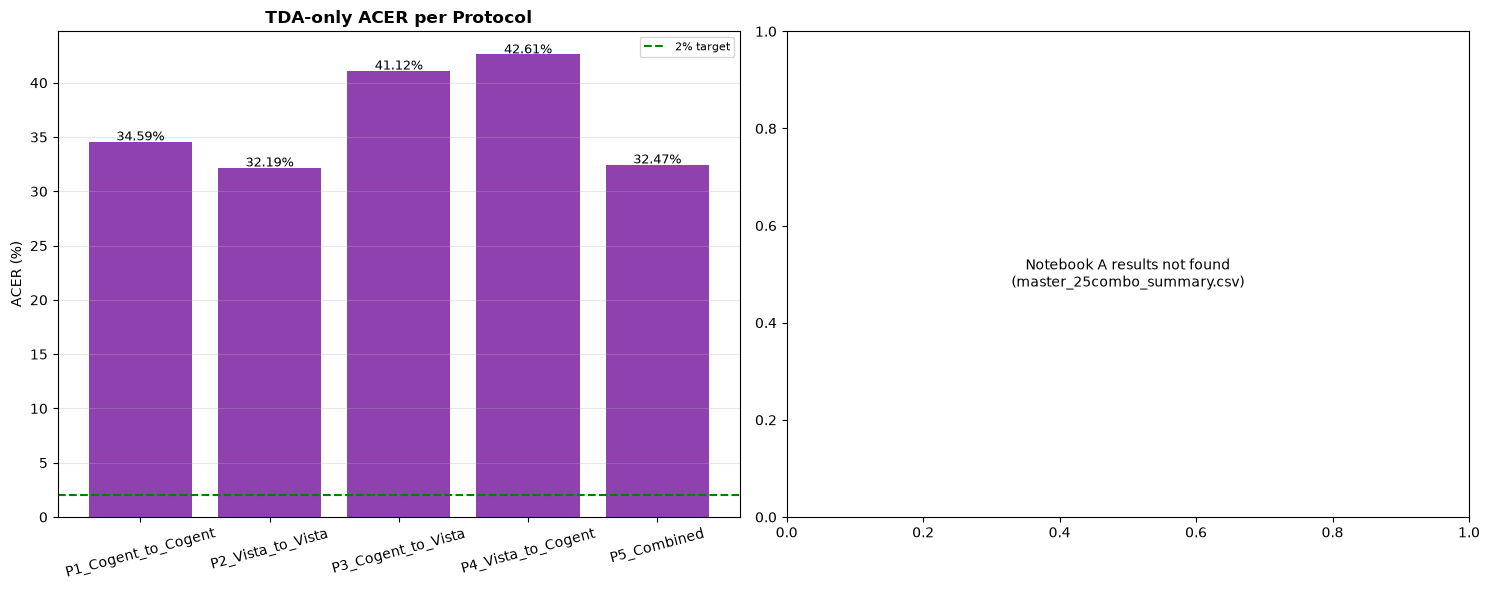

Saved -> tda_only_vs_cnn_acer.png


In [26]:
# Cell 14
# ---------------------------------------------------------------------------
# ACER chart (TDA-only, per protocol) + comparison against CNN+Attention
# baseline (loaded from Notebook A's master_25combo_summary.csv, if present).
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: TDA-only ACER per protocol
bars = axes[0].bar(tda_summary_df['Protocol'], tda_summary_df['ACER'], color='#7B1FA2', alpha=0.85)
for bar, v in zip(bars, tda_summary_df['ACER']):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+0.1, f'{v:.2f}%', ha='center', fontsize=9)
axes[0].axhline(2.0, color='green', lw=1.5, linestyle='--', label='2% target')
axes[0].set_title('TDA-only ACER per Protocol', fontsize=12, fontweight='bold')
axes[0].set_ylabel('ACER (%)'); axes[0].legend(fontsize=8)
axes[0].tick_params(axis='x', rotation=15); axes[0].grid(axis='y', alpha=0.3)

# Right: TDA-only vs CNN-only (best backbone per protocol, from Notebook A)
cnn_summary_path = METRICS_DIR / 'master_25combo_summary.csv'
if cnn_summary_path.exists():
    cnn_df = pd.read_csv(cnn_summary_path)
    best_cnn_per_protocol = cnn_df.loc[cnn_df.groupby('Protocol')['ACER'].idxmin()]
    x = np.arange(len(PROTOCOL_NAMES)); w = 0.35
    cnn_acer = [best_cnn_per_protocol[best_cnn_per_protocol['Protocol']==p]['ACER'].values[0]
                if p in best_cnn_per_protocol['Protocol'].values else np.nan for p in PROTOCOL_NAMES]
    tda_acer = [tda_summary_df[tda_summary_df['Protocol']==p]['ACER'].values[0]
                if p in tda_summary_df['Protocol'].values else np.nan for p in PROTOCOL_NAMES]
    axes[1].bar(x-w/2, cnn_acer, w, label='Best CNN+Attention (NB-A)', color='#1E88E5', alpha=0.85)
    axes[1].bar(x+w/2, tda_acer, w, label='TDA-only (this notebook)', color='#7B1FA2', alpha=0.85)
    axes[1].set_xticks(x); axes[1].set_xticklabels(PROTOCOL_NAMES, rotation=15, ha='right', fontsize=8)
    axes[1].set_title('CNN+Attention (best) vs TDA-only', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('ACER (%)'); axes[1].legend(fontsize=8); axes[1].grid(axis='y', alpha=0.3)
else:
    axes[1].text(0.5, 0.5, 'Notebook A results not found\n(master_25combo_summary.csv)',
                ha='center', va='center', transform=axes[1].transAxes)

plt.tight_layout()
plt.savefig(TDA_FIGURES_DIR / 'tda_only_vs_cnn_acer.png', dpi=140, bbox_inches='tight')
plt.show()
print('Saved -> tda_only_vs_cnn_acer.png')


## 16. Done

In [27]:
# Cell 15
print(f'  Master TDA features (~528 raw)  -> {MASTER_TDA_PATH}')
print(f'  Stability scores                -> {TDA_RAW_DIR}/stability_scores.csv')
print(f'  Per-protocol selected features   -> {TDA_SELECTED_DIR}/*_selected_features.json')
print(f'  Per-protocol scalers (in-memory) -> refit identically in Notebook C via same function')
print(f'  TDA-only models                  -> {TDA_MODELS_DIR}')
print(f'  TDA-only summary                 -> {TDA_MODELS_DIR}/tda_only_summary.csv')
print(f'  DET curves                       -> {TDA_DET_DIR}')

  Master TDA features (~528 raw)  -> C:\Users\sahar\OneDrive\Desktop\EXPLAINABLE_IRIS_PAD\Experiments\Exp5_IIITD_CrossSensor_5Protocol\outputs\tda\raw_features\master_tda_features.csv
  Stability scores                -> C:\Users\sahar\OneDrive\Desktop\EXPLAINABLE_IRIS_PAD\Experiments\Exp5_IIITD_CrossSensor_5Protocol\outputs\tda\raw_features/stability_scores.csv
  Per-protocol selected features   -> C:\Users\sahar\OneDrive\Desktop\EXPLAINABLE_IRIS_PAD\Experiments\Exp5_IIITD_CrossSensor_5Protocol\outputs\tda\selected_features/*_selected_features.json
  Per-protocol scalers (in-memory) -> refit identically in Notebook C via same function
  TDA-only models                  -> C:\Users\sahar\OneDrive\Desktop\EXPLAINABLE_IRIS_PAD\Experiments\Exp5_IIITD_CrossSensor_5Protocol\outputs\tda\models
  TDA-only summary                 -> C:\Users\sahar\OneDrive\Desktop\EXPLAINABLE_IRIS_PAD\Experiments\Exp5_IIITD_CrossSensor_5Protocol\outputs\tda\models/tda_only_summary.csv
  DET curves             